# Implement and Test a PyTorch-Based Classifier

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 2

**Objective:** Build, train, and evaluate a convolutional neural network
(CNN) in PyTorch for binary classification of agricultural vs.
non-agricultural satellite land tiles.

**Dataset:** `images_dataSAT/class_0_non_agri` and `images_dataSAT/class_1_agri`
(3,000 images each, 64x64 RGB).


## 1. Import libraries and packages

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

print("PyTorch:", torch.__version__)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("images_dataSAT")
assert DATA_DIR.exists(), f"'{DATA_DIR}' not found in the working directory."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch: 2.12.1+cu130
Using device: cpu


## 2. Data loading pipeline

We use `ImageDataGenerator`-equivalent functionality in PyTorch — a
`transforms.Compose` pipeline (resizing, normalization, augmentation)
combined with `ImageFolder` and `DataLoader`, then split into
train/validation sets.


In [2]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=train_transform)
print("Classes:", full_dataset.class_to_idx)  # class_0_non_agri -> 0, class_1_agri -> 1

n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(full_dataset, [n_train, n_val], generator=generator)

# Validation set should NOT use train-time augmentation -> rebuild it with eval_transform
val_dataset_plain = datasets.ImageFolder(root=str(DATA_DIR), transform=eval_transform)
val_subset = torch.utils.data.Subset(val_dataset_plain, val_subset.indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train samples: {n_train}, Validation samples: {n_val}")
print(f"Train batches: {len(train_loader)}, Validation batches: {len(val_loader)}")


Classes: {'class_0_non_agri': 0, 'class_1_agri': 1}
Train samples: 4800, Validation samples: 1200
Train batches: 150, Validation batches: 38


## 3. CNN architecture

A multi-layered CNN incorporating `Conv2d` layers, batch normalization,
pooling, and dropout — mirroring the Keras architecture from the previous
lab for a fair later comparison.


In [3]:
class SatelliteCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 1),  # logits; BCEWithLogitsLoss applies sigmoid internally
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


pytorch_model = SatelliteCNN().to(device)
print(pytorch_model)

n_params = sum(p.numel() for p in pytorch_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")


SatelliteCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_fea

## 4. Model training setup

In [4]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=1e-3)


## 5. Training process

We feed data in batches, track training/validation loss and accuracy per
epoch, and monitor performance over the course of training.


In [5]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = (torch.sigmoid(logits) >= 0.5).float()
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            total_loss += loss.item() * labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


EPOCHS = 6
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

t0 = time.perf_counter()
for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(pytorch_model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(pytorch_model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

t1 = time.perf_counter()
print(f"\nTotal training time: {t1 - t0:.1f} s")


Epoch 1/6 - train_loss: 0.0772 - train_acc: 0.9773 - val_loss: 0.0588 - val_acc: 0.9742


Epoch 2/6 - train_loss: 0.0527 - train_acc: 0.9823 - val_loss: 0.0162 - val_acc: 0.9950


Epoch 3/6 - train_loss: 0.0289 - train_acc: 0.9910 - val_loss: 0.0311 - val_acc: 0.9908


Epoch 4/6 - train_loss: 0.0307 - train_acc: 0.9917 - val_loss: 0.2243 - val_acc: 0.9283


Epoch 5/6 - train_loss: 0.0297 - train_acc: 0.9908 - val_loss: 0.0200 - val_acc: 0.9958


Epoch 6/6 - train_loss: 0.0203 - train_acc: 0.9938 - val_loss: 0.1643 - val_acc: 0.9600

Total training time: 232.2 s


## 6. Performance visualization: accuracy and loss curves

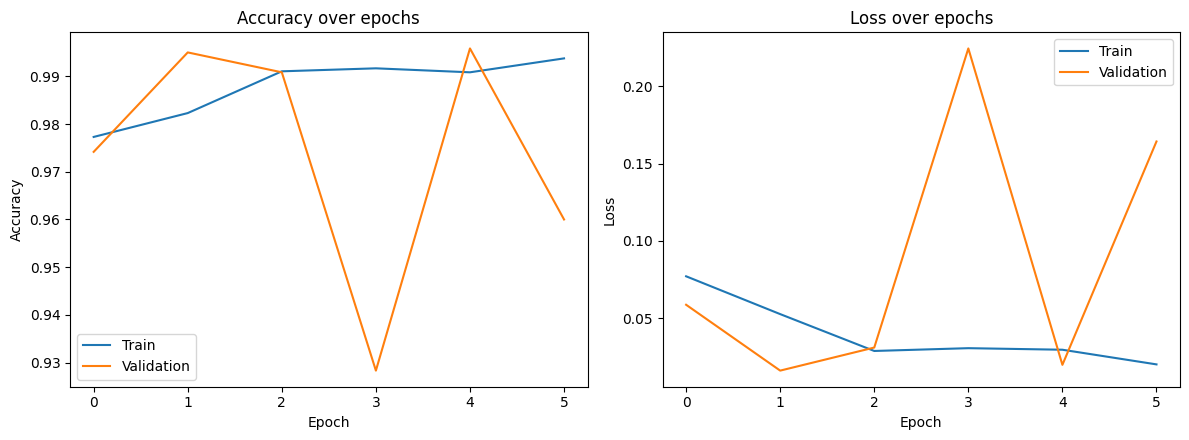

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history["train_acc"], label="Train")
axes[0].plot(history["val_acc"], label="Validation")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history["train_loss"], label="Train")
axes[1].plot(history["val_loss"], label="Validation")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Model evaluation

In [7]:
pytorch_model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = pytorch_model(images)
        preds = (torch.sigmoid(logits) >= 0.5).float().cpu().numpy().ravel()
        y_pred.extend(preds)
        y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Validation accuracy : {acc:.4f}")
print(f"Validation precision: {prec:.4f}")
print(f"Validation recall   : {rec:.4f}")
print(f"Validation F1-score : {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix (rows=true, cols=pred):")
print(f"                 pred non-agri  pred agri")
print(f"true non-agri    {cm[0,0]:>12}  {cm[0,1]:>9}")
print(f"true agri        {cm[1,0]:>12}  {cm[1,1]:>9}")


Validation accuracy : 0.9600
Validation precision: 0.9925
Validation recall   : 0.9236
Validation F1-score : 0.9568

Confusion matrix (rows=true, cols=pred):
                 pred non-agri  pred agri
true non-agri             620          4
true agri                  44        532


## 8. Save the trained model (needed for later labs)

In [8]:
MODELS_DIR = Path(".")
MODELS_DIR.mkdir(exist_ok=True)
torch.save(pytorch_model.state_dict(), MODELS_DIR / "pytorch_cnn_classifier.pt")
print(f"Saved model weights to {'pytorch_cnn_classifier.pt'}")


Saved model weights to pytorch_cnn_classifier.pt


## Summary

We built, trained, and evaluated a deep learning model for image
classification using PyTorch:

* **Data loading pipeline** — `ImageFolder` + `DataLoader` for efficient,
  on-the-fly image loading, resizing, normalization, and augmentation.
* **CNN architecture** — a multi-layered CNN incorporating `Conv2d`
  layers, batch normalization, pooling, and dropout.
* **Model training setup** — Adam optimizer, `BCEWithLogitsLoss`, tracking
  accuracy and loss per epoch.
* **Training process** — batched training over multiple epochs.
* **Performance visualization** — accuracy/loss curves for learning
  progress and overfitting detection.
* **Model evaluation** — accuracy, precision, recall, F1-score, and a
  confusion matrix.
